### Necessary Imports


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.signal.windows import hamming

### Exection of Assignment

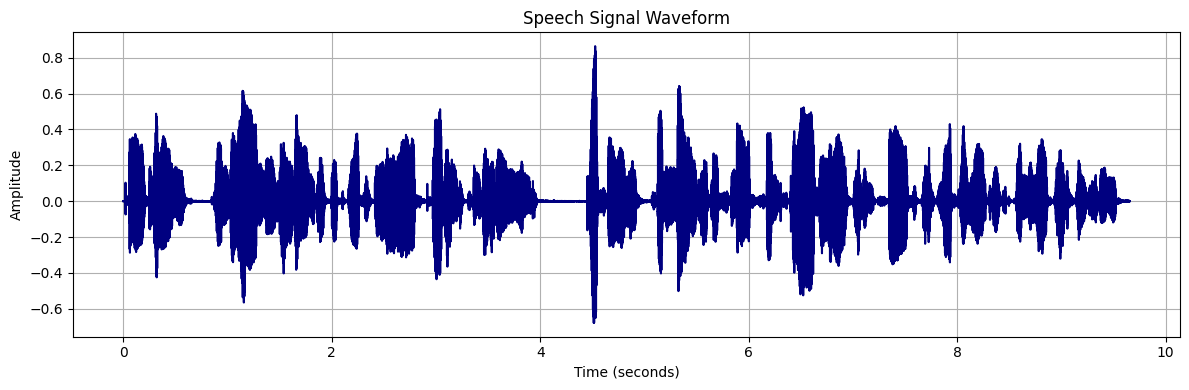

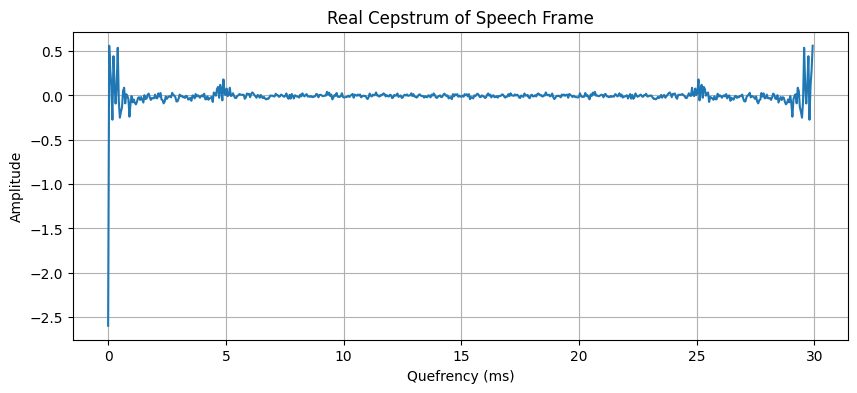

Estimated Pitch Period: 5.17 ms
Estimated Fundamental Frequency (F0): 193.42 Hz


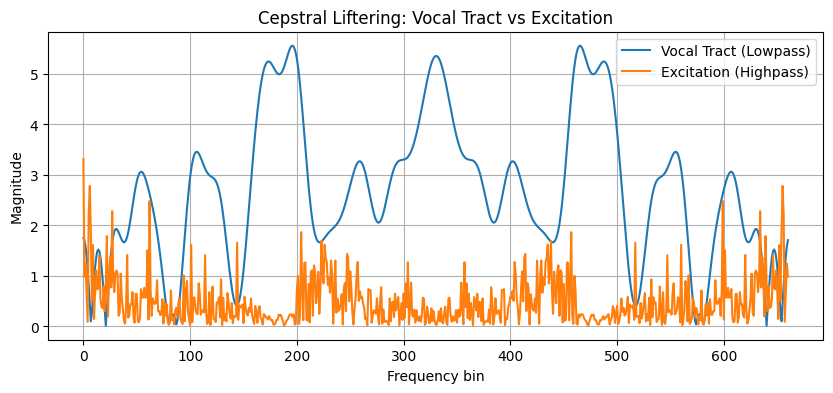

In [3]:
# Load audio file
y, sr = librosa.load('/content/LJ001-0001.wav', sr=None)
duration = len(y) / sr
time = np.linspace(0, duration, len(y))

# Plot the speech waveform
plt.figure(figsize=(12, 4))
plt.plot(time, y, color='navy')
plt.title("Speech Signal Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

# Frame parameters
frame_duration = 0.03
frame_length = int(frame_duration * sr)
frame_start = 10000
frame = y[frame_start:frame_start + frame_length] * hamming(frame_length)

# A. Compute Real Cepstrum
spectrum = np.fft.fft(frame)
log_magnitude = np.log(np.abs(spectrum) + 1e-10)
real_cepstrum = np.fft.ifft(log_magnitude).real

# B. Plot Cepstrum
quefrency = np.arange(len(real_cepstrum)) / sr

plt.figure(figsize=(10, 4))
plt.plot(quefrency * 1000, real_cepstrum)
plt.title("Real Cepstrum of Speech Frame")
plt.xlabel("Quefrency (ms)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# C. Estimate Pitch from Cepstrum
min_pitch_period = int(0.005 * sr)
max_pitch_period = int(0.02 * sr)

cepstrum_roi = real_cepstrum[min_pitch_period:max_pitch_period]
peak_index = np.argmax(cepstrum_roi) + min_pitch_period
pitch_period = peak_index / sr
f0 = sr / peak_index

print(f"Estimated Pitch Period: {pitch_period * 1000:.2f} ms")
print(f"Estimated Fundamental Frequency (F0): {f0:.2f} Hz")

# D. Cepstral Liftering
# Low-pass liftering (retain vocal tract)
lifter_len = 30
lowpass_cepstrum = np.copy(real_cepstrum)
lowpass_cepstrum[lifter_len:-lifter_len] = 0
vocal_tract = np.fft.fft(lowpass_cepstrum)

# High-pass liftering (retain excitation)
highpass_cepstrum = real_cepstrum - lowpass_cepstrum
excitation = np.fft.fft(highpass_cepstrum)

# Plot separated components
plt.figure(figsize=(10, 4))
plt.plot(np.abs(vocal_tract), label="Vocal Tract (Lowpass)")
plt.plot(np.abs(excitation), label="Excitation (Highpass)")
plt.title("Cepstral Liftering: Vocal Tract vs Excitation")
plt.xlabel("Frequency bin")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)
plt.show()